# 🚀 Project Hail Mary: The Adrian Descent
## Tabular Q-Learning for Autonomous Probe Control

> *"Amaze! You write smart-code. Probe lands safe, question?"* — Rocky

**Objective:** Train a Tabular Q-Learning agent to softly land a probe in Adrian's turbulent atmosphere despite massive gravity and chaotic wind conditions.

---
### Architecture Overview
- **Part 1:** Deterministic physics baseline (Kinematics)
- **Part 2:** Stochastic MDP formulation (Wind states)
- **Part 3:** Q-Learning Agent with discretization
- **Part 4:** Reward shaping (avoiding the Cowardly Agent)
- **Part 5:** Training loop + evaluation
- **Part 6:** Bridge to OS Scheduler (Design Questions)
- **Bonus:** Variable Spin-Drive (3-action space)

---
## Cell 0: Imports & Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import time
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

# Seed for reproducibility
np.random.seed(42)
print("✅ Imports successful. Mission systems online.")

✅ Imports successful. Mission systems online.


---
## Part 1 & 2: ProbeEnv — Physics Engine + Stochastic MDP

### Rocky's Analytics — Pre-code Calculations

**Terminal Velocity** (when `F_gravity = F_drag`, thrust OFF, v < 0 so sign(-v) = +1):

At h ≈ 0:
$$F_{gravity} = m \cdot g = 1000 \times 13.7 = 13700 \text{ N}$$
$$F_{drag} = k_{drag} \cdot v^2 \Rightarrow 13700 = 2.0 \cdot v^2 \Rightarrow v_{terminal} = \sqrt{6850} \approx -82.8 \text{ m/s}$$

The safe catch velocity is `v ≥ −3.0 m/s`. Terminal velocity is **≈ −82.8 m/s**, far exceeding the safe limit → the agent *must* use the spin-drive.

**Maximum Net Acceleration** (thrust ON, v = 0, h = 0):
$$F_{net} = -mg + F_{thrust} + 0 = -13700 + 25000 = 11300 \text{ N}$$
$$a_{max} = 11300 / 1000 = +11.3 \text{ m/s}^2 \text{ (upward)}$$

The thrust **can** overcome gravity → a purely "thrust always ON" agent would ascend forever (Cowardly Agent risk).

In [2]:
# Quick verification of Rocky's Analytics
m       = 1000.0        # kg — probe mass
g       = 13.7          # m/s² — Adrian surface gravity
R_adrian= 10_700_000.0  # m — radius of Adrian
k_drag  = 2.0           # drag coefficient (high-density CO2 atmosphere)
F_thrust= 25_000.0      # N — spin-drive thrust
dt      = 0.1           # s — integration time step

# Terminal velocity: k_drag * v^2 = m * g  →  v = sqrt(m*g / k_drag)
v_terminal = -np.sqrt((m * g) / k_drag)   # negative = downward
print(f"📐 Terminal Velocity (thrust OFF): {v_terminal:.2f} m/s")
print(f"   Safe catch limit: ≥ -3.0 m/s  →  Terminal speed is {abs(v_terminal/3):.1f}x too fast!")

# Max net force at h=0, v=0, thrust ON
F_net_max = -m * g * (1 - 0 / R_adrian) + F_thrust  # drag=0 since v=0
a_max     = F_net_max / m
print(f"\n📐 Max Net Acceleration (thrust ON, v=0, h=0): {a_max:.2f} m/s²  (positive = upward)")
print(f"   Thrust CAN overpower gravity → agent could hover/ascend indefinitely (Cowardly Agent risk!)")

📐 Terminal Velocity (thrust OFF): -82.76 m/s
   Safe catch limit: ≥ -3.0 m/s  →  Terminal speed is 27.6x too fast!

📐 Max Net Acceleration (thrust ON, v=0, h=0): 11.30 m/s²  (positive = upward)
   Thrust CAN overpower gravity → agent could hover/ascend indefinitely (Cowardly Agent risk!)


In [3]:
class ProbeEnv:
    """
    Adrian Descent Physics Environment.

    Implements a stochastic MDP for probe descent in Adrian's atmosphere.
    State: (altitude h [m], velocity v [m/s], wind_index {0,1,2})
    Action: 0 = Thrust OFF, 1 = Thrust ON  (binary spin-drive)
    """

    # ── Physical constants ────────────────────────────────────────────────
    PROBE_MASS  = 1000.0        # kg
    GRAVITY     = 13.7          # m/s²  (Adrian surface gravity)
    R_ADRIAN    = 10_700_000.0  # m     (planet radius)
    K_DRAG_BASE = 2.0           # base drag coefficient
    F_THRUST    = 25_000.0      # N     (spin-drive thrust)
    DT          = 0.1           # s     (Euler integration step)

    # ── Mission parameters ────────────────────────────────────────────────
    INITIAL_ALTITUDE  = 1000.0  # m  — drop altitude
    MAX_ALTITUDE      = 1200.0  # m  — runaway threshold
    SAFE_VELOCITY     = -3.0    # m/s — threshold for a soft catch
    MAX_STEPS         = 3000    # steps before forced termination (300 s)

    # ── Wind states ───────────────────────────────────────────────────────
    #   0 = Calm (1.0× drag)   1 = Gusty (1.5× drag)   2 = Adrian Gale (2.5× drag)
    WIND_MULTIPLIERS = np.array([1.0, 1.5, 2.5])

    # Transition Probability Matrix  P[current_wind, next_wind]
    # Weather has momentum: high probability of staying in same state,
    # gradual shifts rather than sudden jumps (simulates atmospheric inertia).
    WIND_TRANSITION = np.array([
        [0.80, 0.15, 0.05],   # Calm  → [Calm, Gusty, Gale]
        [0.20, 0.60, 0.20],   # Gusty → [Calm, Gusty, Gale]
        [0.05, 0.25, 0.70],   # Gale  → [Calm, Gusty, Gale]
    ])

    # ── Reward constants ──────────────────────────────────────────────────
    R_ENGINE_BURN    = -0.5    # per-step fuel cost when thrust is ON
    R_SOFT_CATCH     = +500.0  # massive reward for a gentle landing
    R_RUNAWAY        = -200.0  # probe escaped to orbit OR exceeded step limit
    R_ALIVE          = -0.1    # tiny time-pressure penalty per step (incentivise efficiency)
    # Crash penalty is DYNAMIC: R_CRASH = -1.0 * |v|  (faster = worse)
    R_CRASH_SCALE    = -1.0

    def __init__(self):
        """
        Initialise the environment. Call reset() before the first episode.
        """
        self.h        = self.INITIAL_ALTITUDE
        self.v        = 0.0
        self.wind_idx = 0
        self.steps    = 0

    # ─────────────────────────────────────────────────────────────────────
    def reset(self):
        """
        Reset probe to drop conditions.
        Returns:
            state (tuple): (altitude, velocity, wind_index)
        """
        self.h        = self.INITIAL_ALTITUDE
        self.v        = 0.0
        self.wind_idx = 0   # always start in Calm — storms build up naturally
        self.steps    = 0
        return (self.h, self.v, self.wind_idx)

    # ─────────────────────────────────────────────────────────────────────
    def _compute_forces(self, action):
        """
        Compute net force using Adrian's Newtonian kinematics.

        Gravity increases slightly as probe descends (altitude term).
        Drag opposes velocity direction and is scaled by current wind state.
        Thrust is a binary ON/OFF spin-drive (upward = positive).

        Returns:
            F_net (float): Net force in Newtons (positive = upward)
        """
        # 1. Gravity — increases as probe nears surface
        F_gravity = -self.PROBE_MASS * self.GRAVITY * (1 - self.h / self.R_ADRIAN)

        # 2. Thrust — applied upward if action == 1
        F_thrust = self.F_THRUST if action == 1 else 0.0

        # 3. Drag — opposes velocity; scaled by current wind multiplier
        wind_mult = self.WIND_MULTIPLIERS[self.wind_idx]
        F_drag = self.K_DRAG_BASE * wind_mult * (self.v ** 2) * np.sign(-self.v)

        return F_gravity + F_thrust + F_drag

    # ─────────────────────────────────────────────────────────────────────
    def _transition_wind(self):
        """
        Stochastically transition wind state using the Markov transition matrix.
        This gives wind momentum — storms build and fade gradually rather than
        teleporting randomly each step (satisfies the Markov Property because
        next state depends only on current wind_idx, not history).
        """
        probs = self.WIND_TRANSITION[self.wind_idx]          # row for current state
        self.wind_idx = np.random.choice([0, 1, 2], p=probs) # sample next state

    # ─────────────────────────────────────────────────────────────────────
    def step(self, action):
        """
        Advance the simulation by one time step (dt = 0.1 s).

        Physics → Wind transition → Terminal checks → Reward shaping.

        Args:
            action (int): 0 = thrust OFF, 1 = thrust ON

        Returns:
            next_state (tuple): (h, v, wind_idx)
            reward     (float): shaped reward signal
            done       (bool):  True if episode has ended
            info       (dict):  {'outcome': str} for logging
        """
        self.steps += 1

        # ── 1. Physics update (Euler integration) ────────────────────────
        F_net = self._compute_forces(action)
        a     = F_net / self.PROBE_MASS          # Newton's 2nd law
        self.v = self.v + a * self.DT            # velocity update
        self.h = self.h + self.v * self.DT       # altitude update

        # ── 2. Stochastic wind transition ────────────────────────────────
        self._transition_wind()

        # ── 3. Terminal condition checks + reward shaping ─────────────────
        reward = self.R_ALIVE  # baseline time-pressure penalty each step

        # Fuel cost when engine is burning
        if action == 1:
            reward += self.R_ENGINE_BURN

        # ── TERMINAL: Reached surface ────────────────────────────────────
        if self.h <= 0.0:
            if self.v >= self.SAFE_VELOCITY:
                # ✅ Soft catch! Taumoeba sample secured.
                reward += self.R_SOFT_CATCH
                return (self.h, self.v, self.wind_idx), reward, True, {'outcome': 'soft_catch'}
            else:
                # 💥 Crushed by pressure — dynamic penalty scales with impact speed
                reward += self.R_CRASH_SCALE * abs(self.v)
                return (self.h, self.v, self.wind_idx), reward, True, {'outcome': 'crash'}

        # ── TERMINAL: Runaway probe (escaped to orbit) ───────────────────
        if self.h > self.MAX_ALTITUDE:
            reward += self.R_RUNAWAY
            return (self.h, self.v, self.wind_idx), reward, True, {'outcome': 'runaway'}

        # ── TERMINAL: Exceeded maximum steps (hovering indefinitely) ─────
        if self.steps >= self.MAX_STEPS:
            reward += self.R_RUNAWAY
            return (self.h, self.v, self.wind_idx), reward, True, {'outcome': 'timeout'}

        # ── Continuing: return updated state ─────────────────────────────
        return (self.h, self.v, self.wind_idx), reward, False, {'outcome': 'flying'}


print("✅ ProbeEnv class defined.")

# Quick sanity check: one step with thrust ON from initial state
_env = ProbeEnv()
_s0  = _env.reset()
_s1, _r, _d, _info = _env.step(1)
print(f"   State after 1 step (thrust ON): h={_s1[0]:.3f} m, v={_s1[1]:.4f} m/s, wind={_s1[2]}, reward={_r:.2f}")

✅ ProbeEnv class defined.
   State after 1 step (thrust ON): h=1000.113 m, v=1.1301 m/s, wind=0, reward=-0.60


---
## Part 2: Design Question — Memory in the Storm

**Q: How does a Transition Probability Matrix simulate weather better than a random die?**

**A:** Real wind has **atmospheric inertia** — a storm doesn't teleport from Gale to Calm in one second. The TPM encodes this by giving each wind state a **high self-transition probability** (e.g., Gale stays Gale with P=0.70). This means:
- Calm spells last many steps before a gust builds (P=0.80 self-loop)
- Adrian Gales persist for extended periods (P=0.70 self-loop)
- Transitions are gradual: Calm → Gusty → Gale, not Calm → Gale instantly

A random 3-sided die would give every state an equal 1/3 chance every step — producing unrealistic flickering between Calm and Gale within the same second. The Markov chain produces **autocorrelated** wind sequences that match real meteorological phenomena.

---
## Part 3: ProbeAgent — Tabular Q-Learning

### Design Question: Exploration vs. Exploitation

Decay: $\epsilon_{5000} = 1.0 \times 0.999^{5000}$

In [4]:
# Exploration rate after 5000 episodes
eps_0   = 1.0
decay   = 0.999
eps_5k  = eps_0 * (decay ** 5000)
print(f"Exploration rate after 5,000 episodes: ε = {eps_5k:.6f} ({eps_5k*100:.4f}%)")
print(f"→ The agent is {(1-eps_5k)*100:.2f}% exploiting — almost fully greedy by episode 5000.")
print(f"  After 15,000 episodes: ε = {eps_0 * decay**15000:.8f} (essentially pure exploitation)")

Exploration rate after 5,000 episodes: ε = 0.006721 (0.6721%)
→ The agent is 99.33% exploiting — almost fully greedy by episode 5000.
  After 15,000 episodes: ε = 0.00000030 (essentially pure exploitation)


In [5]:
class ProbeAgent:
    """
    Tabular Q-Learning agent for the Adrian Descent problem.

    Discretizes the continuous (h, v) state space into buckets and
    maintains a Q-table of shape (n_alt_bins, n_vel_bins, n_wind, n_actions).

    Q-table size = 50 × 60 × 3 × 2 = 18,000 entries  (manageable)
    """

    # ── Discretization config ─────────────────────────────────────────────
    # Altitude: 0 m to 1200 m  → 50 bins
    ALT_BINS  = 50
    ALT_LOW   = 0.0
    ALT_HIGH  = 1200.0

    # Velocity: -100 m/s (fast descent) to +30 m/s (climbing) → 60 bins
    VEL_BINS  = 60
    VEL_LOW   = -100.0
    VEL_HIGH  =  30.0

    N_WIND    = 3   # wind states: Calm / Gusty / Gale
    N_ACTIONS = 2   # binary spin-drive: OFF / ON

    # ── Q-learning hyperparameters ────────────────────────────────────────
    ALPHA   = 0.1    # learning rate — how fast Q-values update
    GAMMA   = 0.99   # discount factor — future rewards are ~99% as valuable as immediate
    EPS_START = 1.0  # initial exploration rate
    EPS_MIN   = 0.01 # minimum exploration (always explore 1% of the time)
    EPS_DECAY = 0.999# multiplicative decay per episode

    def __init__(self):
        """
        Initialise Q-table to zeros and set up discretization bin edges.
        """
        # Q-table: Q[alt_bin, vel_bin, wind, action] = expected cumulative reward
        self.Q = np.zeros((self.ALT_BINS, self.VEL_BINS, self.N_WIND, self.N_ACTIONS))

        # Pre-compute bin edges for np.digitize (excludes endpoints)
        self.alt_edges = np.linspace(self.ALT_LOW, self.ALT_HIGH, self.ALT_BINS - 1)
        self.vel_edges = np.linspace(self.VEL_LOW, self.VEL_HIGH, self.VEL_BINS - 1)

        self.epsilon = self.EPS_START

        table_size = self.ALT_BINS * self.VEL_BINS * self.N_WIND * self.N_ACTIONS
        print(f"   Q-table shape: {self.Q.shape}  →  {table_size:,} entries")

    # ─────────────────────────────────────────────────────────────────────
    def discretize_state(self, raw_state):
        """
        Map continuous (h, v, wind_idx) to discrete integer indices.

        np.digitize returns the bin index [0, n_bins-1] after clipping.

        Args:
            raw_state (tuple): (h: float, v: float, wind_idx: int)

        Returns:
            (alt_bin, vel_bin, wind_idx)  — all integers, safe for Q-table indexing
        """
        h, v, wind = raw_state

        # Clip values to valid range before digitizing
        h_clipped = np.clip(h, self.ALT_LOW, self.ALT_HIGH)
        v_clipped = np.clip(v, self.VEL_LOW, self.VEL_HIGH)

        # np.digitize: returns index such that edges[i-1] <= x < edges[i]
        alt_bin = int(np.digitize(h_clipped, self.alt_edges))
        vel_bin = int(np.digitize(v_clipped, self.vel_edges))

        # Safety clamp (digitize can return n_bins if x == max)
        alt_bin = min(alt_bin, self.ALT_BINS - 1)
        vel_bin = min(vel_bin, self.VEL_BINS - 1)

        return (alt_bin, vel_bin, int(wind))

    # ─────────────────────────────────────────────────────────────────────
    def choose_action(self, state):
        """
        ε-greedy action selection.

        With probability ε → random action (explore the unknown).
        With probability (1-ε) → greedy: pick action with highest Q-value (exploit).

        Args:
            state (tuple): discretized (alt_bin, vel_bin, wind)

        Returns:
            action (int): 0 or 1
        """
        if np.random.random() < self.epsilon:
            return np.random.randint(0, self.N_ACTIONS)  # explore
        else:
            alt_bin, vel_bin, wind = state
            return int(np.argmax(self.Q[alt_bin, vel_bin, wind]))  # exploit

    # ─────────────────────────────────────────────────────────────────────
    def learn(self, state, action, reward, next_state, done):
        """
        Bellman equation update — Temporal Difference (TD) learning.

        Q(s,a) ← Q(s,a) + α · [r + γ · max_a' Q(s',a') - Q(s,a)]
                                └──────── TD target ────────┘  └─ TD error ─┘

        If done=True, there is no future state, so the target = r only.

        Args:
            state      (tuple): discretized current state
            action     (int):   action taken
            reward     (float): reward received
            next_state (tuple): discretized next state
            done       (bool):  whether episode ended
        """
        a_b, v_b, w   = state
        na_b, nv_b, nw = next_state

        # Current Q-value estimate for (state, action)
        current_Q = self.Q[a_b, v_b, w, action]

        # TD target: immediate reward + discounted best future value
        if done:
            td_target = reward  # no future after terminal state
        else:
            td_target = reward + self.GAMMA * np.max(self.Q[na_b, nv_b, nw])

        # TD error = target - estimate
        td_error = td_target - current_Q

        # Update Q-table
        self.Q[a_b, v_b, w, action] += self.ALPHA * td_error

    # ─────────────────────────────────────────────────────────────────────
    def decay_epsilon(self):
        """
        Decay exploration rate after each episode (multiplicative decay).
        Floor at EPS_MIN to always retain a tiny exploration buffer.
        """
        self.epsilon = max(self.EPS_MIN, self.epsilon * self.EPS_DECAY)


print("✅ ProbeAgent class defined.")
_agent = ProbeAgent()

✅ ProbeAgent class defined.
   Q-table shape: (50, 60, 3, 2)  →  18,000 entries


---
## Part 4: Reward Design — Design Questions

### The Cowardly Agent

**Q: Heavy crash penalty + tiny fuel cost → what degenerate behaviour?**  
**A:** The agent learns to **hover indefinitely** or **escape to orbit** — it fires thrust continuously to stay high, paying only small fuel costs rather than risk the huge crash penalty. It exploits the fact that "not crashing" is rewarded more than "landing". This is the Cowardly Agent.

**Q: Sparse reward (+1000 only at success) → why does the agent struggle?**  
**A:** With no intermediate rewards, the agent receives zero signal for 2999 steps and +1000 only at step 3000 *if* it randomly happens to land softly. The probability of stumbling upon a soft landing via random actions is near zero, so the agent never gets a positive TD update and stays stuck in the uniform-zero Q-table. This is the **credit assignment problem** — there's no gradient to guide the agent towards the goal.

**Solution:** We use:
- **Time pressure** (−0.1/step) → discourages hovering
- **Fuel cost** (−0.5/step when ON) → discourages wasting fuel
- **Dynamic crash penalty** (−1.0 × |v|) → much worse for high-speed impacts
- **Runaway penalty** (−200) → punishes escaping to orbit

---
## Part 5: Mission Control — Terminal Renderer

In [6]:
def render_probe_ascii(h, max_h, v, action, wind, step_count, is_jupyter=False):
    """
    High-framerate ASCII terminal renderer (provided tooling, verbatim from spec).
    Call after agent selects action but BEFORE stepping environment.
    """
    if is_jupyter:
        clear_output(wait=True)
    else:
        os.system('clear' if os.name == 'posix' else 'cls')

    term_lines = 40

    if h > 150.0:
        display_max = max_h
        zoom_str = "[ CAMERA: WIDE ANGLE (1000 m) ]"
    else:
        display_max = 150.0
        zoom_str = "[ CAMERA: TARGET APPROACH (150 m) ]"

    pos = int((h / display_max) * term_lines)
    pos = max(0, min(term_lines, pos))

    wind_strs  = ["~ Calm ~", " Gusty  ", " Adrian Gale "]
    thrust_str = " [####] ON " if action == 1 else "[      ] OFF"

    print(f" T+{step_count:03d}s | ALT: {h:6.1f}m | VEL: {v:7.1f}m/s | THRUST: {thrust_str} | WIND: {wind_strs[wind]}")
    print(f" {zoom_str}")
    print("-" * 75)

    for i in range(term_lines, -1, -1):
        if i == pos:
            if action == 1:
                print("        /\\")
                print("        | |")
                print("       /WW \\")
                print("       ||   <-- spin-drive")
            else:
                print("        /\\")
                print("        | |")
                print("       /-- \\")
                print("            ")
        else:
            if i % 10 == 0:
                print(f" {int((i/term_lines)*display_max):4d}m +------------------------")
            else:
                print("       |")

    print(" ======================= [ TAUMOEBA TARGET ] =======================")
    time.sleep(0.04)


print("✅ render_probe_ascii() defined.")

✅ render_probe_ascii() defined.


---
## Part 5: Training Loop — 20,000 Episodes

In [7]:
def train(n_episodes=20_000, print_interval=1000):
    """
    Full Q-Learning training loop.

    Each episode:
      1. Reset environment → get initial state
      2. Loop until done:
           a. Discretize state
           b. Agent chooses action (ε-greedy)
           c. Environment steps forward → (next_state, reward, done)
           d. Agent learns from transition (Bellman update)
           e. Accumulate reward
      3. Decay ε
      4. Log episode result

    Args:
        n_episodes     (int): total training episodes
        print_interval (int): how often to print a status line

    Returns:
        agent      (ProbeAgent): trained agent
        rewards    (list):       total reward per episode
        outcomes   (list):       outcome string per episode
    """
    env    = ProbeEnv()
    agent  = ProbeAgent()
    print(f"\n🚀 Beginning {n_episodes:,} episode training run...")
    print(f"   Q-table size: {agent.Q.size:,} entries")
    print(f"   α={agent.ALPHA}  γ={agent.GAMMA}  ε_start={agent.EPS_START}  ε_decay={agent.EPS_DECAY}\n")

    all_rewards  = []
    all_outcomes = []          # 'soft_catch' / 'crash' / 'runaway' / 'timeout'

    for ep in range(1, n_episodes + 1):
        raw_state = env.reset()
        state     = agent.discretize_state(raw_state)
        ep_reward = 0.0
        done      = False
        outcome   = 'timeout'

        while not done:
            # 1. Choose action
            action = agent.choose_action(state)

            # 2. Step environment
            raw_next, reward, done, info = env.step(action)
            next_state = agent.discretize_state(raw_next)

            # 3. Q-table update (Bellman)
            agent.learn(state, action, reward, next_state, done)

            # 4. Accumulate
            ep_reward += reward
            state      = next_state

            if done:
                outcome = info['outcome']

        # Decay exploration after each full episode
        agent.decay_epsilon()
        all_rewards.append(ep_reward)
        all_outcomes.append(outcome)

        # ── Status print ─────────────────────────────────────────────────
        if ep % print_interval == 0:
            recent_rewards  = all_rewards[-print_interval:]
            recent_outcomes = all_outcomes[-print_interval:]
            avg_r   = np.mean(recent_rewards)
            success = recent_outcomes.count('soft_catch') / print_interval * 100
            crashes = recent_outcomes.count('crash')      / print_interval * 100
            print(f"  Ep {ep:>6,}/{n_episodes:,} | ε={agent.epsilon:.4f} | "
                  f"Avg Reward={avg_r:>8.1f} | "
                  f"✅ Landings={success:4.1f}% | "
                  f"💥 Crashes={crashes:4.1f}%")

    print("\n✅ Training complete!")
    return agent, all_rewards, all_outcomes


print("✅ train() function defined.")

✅ train() function defined.


In [8]:
# ── RUN TRAINING ───────────────────────────────────────────────────────────
trained_agent, episode_rewards, episode_outcomes = train(n_episodes=20_000, print_interval=1000)

   Q-table shape: (50, 60, 3, 2)  →  18,000 entries

🚀 Beginning 20,000 episode training run...
   Q-table size: 18,000 entries
   α=0.1  γ=0.99  ε_start=1.0  ε_decay=0.999

  Ep  1,000/20,000 | ε=0.3677 | Avg Reward=  -124.3 | ✅ Landings= 0.1% | 💥 Crashes=99.9%
  Ep  2,000/20,000 | ε=0.1352 | Avg Reward=   -80.9 | ✅ Landings= 0.1% | 💥 Crashes=99.9%
  Ep  3,000/20,000 | ε=0.0497 | Avg Reward=    58.2 | ✅ Landings=27.6% | 💥 Crashes=72.4%
  Ep  4,000/20,000 | ε=0.0183 | Avg Reward=   210.0 | ✅ Landings=61.2% | 💥 Crashes=38.8%
  Ep  5,000/20,000 | ε=0.0100 | Avg Reward=   274.6 | ✅ Landings=76.3% | 💥 Crashes=23.7%
  Ep  6,000/20,000 | ε=0.0100 | Avg Reward=   311.6 | ✅ Landings=84.9% | 💥 Crashes=15.1%
  Ep  7,000/20,000 | ε=0.0100 | Avg Reward=   311.5 | ✅ Landings=85.4% | 💥 Crashes=14.6%
  Ep  8,000/20,000 | ε=0.0100 | Avg Reward=   328.1 | ✅ Landings=88.6% | 💥 Crashes=11.4%
  Ep  9,000/20,000 | ε=0.0100 | Avg Reward=   316.7 | ✅ Landings=86.0% | 💥 Crashes=14.0%
  Ep 10,000/20,000 | ε=0.

---
## Part 5: Learning Curves

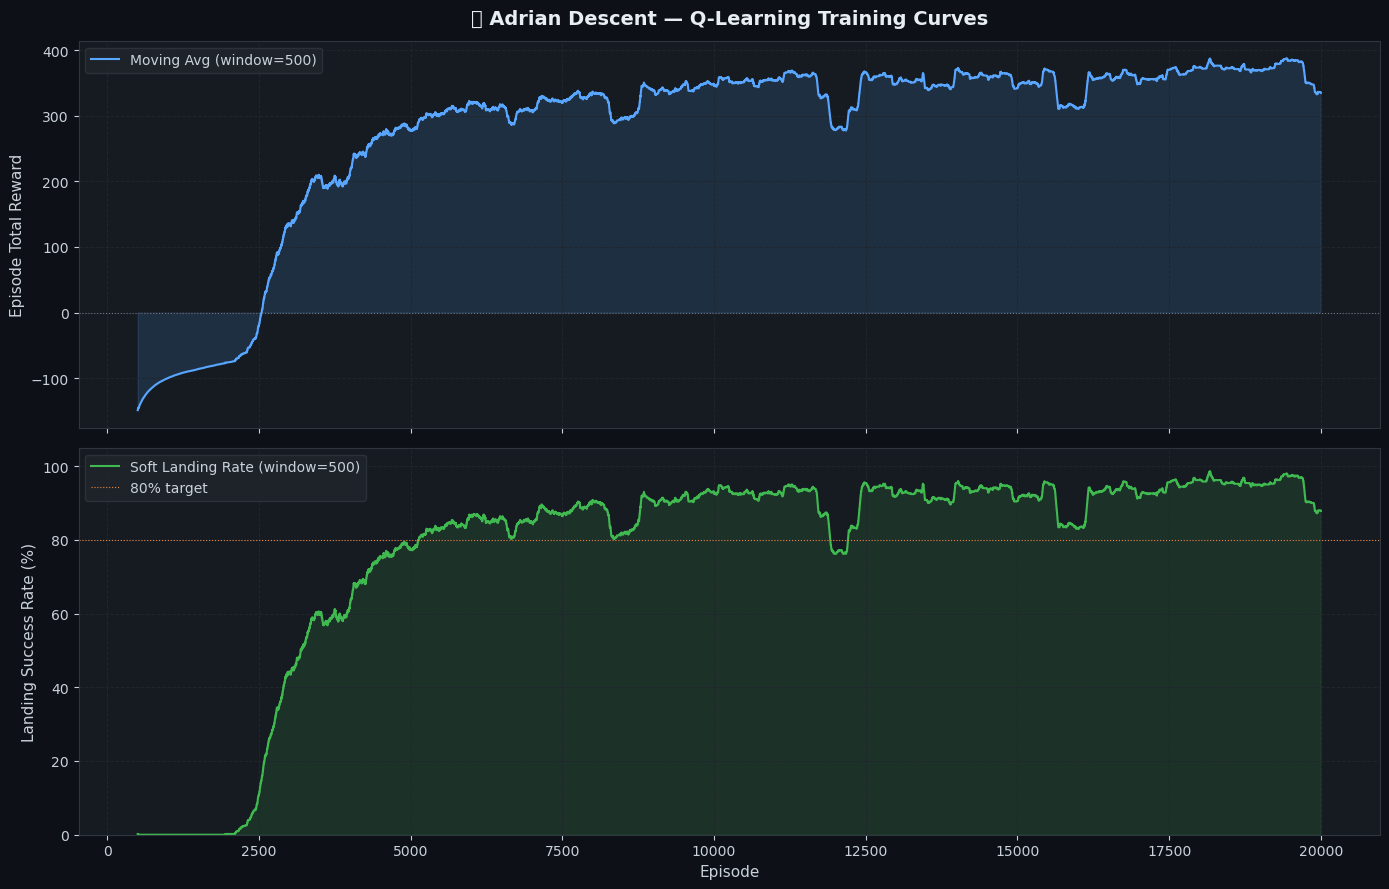

✅ Learning curve saved to 'learning_curve.png'


In [9]:
def plot_learning_curves(rewards, outcomes, window=500, save_path='learning_curve.png'):
    """
    Plot two subplots:
      1. Moving average of episode total reward
      2. Moving average of landing success rate (%)

    Args:
        rewards   (list): total reward per episode
        outcomes  (list): outcome string per episode
        window    (int):  smoothing window size
        save_path (str):  file to save figure
    """
    n = len(rewards)
    successes = [1.0 if o == 'soft_catch' else 0.0 for o in outcomes]

    # Compute moving averages
    def moving_avg(data, w):
        return np.convolve(data, np.ones(w) / w, mode='valid')

    avg_rewards  = moving_avg(rewards,   window)
    avg_success  = moving_avg(successes, window) * 100.0  # → percentage
    x_axis       = np.arange(window, n + 1)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
    fig.patch.set_facecolor('#0d1117')

    for ax in (ax1, ax2):
        ax.set_facecolor('#161b22')
        ax.tick_params(colors='#c9d1d9')
        ax.xaxis.label.set_color('#c9d1d9')
        ax.yaxis.label.set_color('#c9d1d9')
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363d')
        ax.grid(True, color='#21262d', linewidth=0.7, linestyle='--')

    # Plot 1: Episode Reward
    ax1.plot(x_axis, avg_rewards, color='#58a6ff', linewidth=1.5, label=f'Moving Avg (window={window})')
    ax1.fill_between(x_axis, avg_rewards, alpha=0.15, color='#58a6ff')
    ax1.axhline(0, color='#6e7681', linewidth=0.8, linestyle=':')
    ax1.set_ylabel('Episode Total Reward', fontsize=11)
    ax1.set_title('🚀 Adrian Descent — Q-Learning Training Curves', color='#e6edf3',
                  fontsize=14, fontweight='bold', pad=12)
    ax1.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#c9d1d9')

    # Plot 2: Success Rate
    ax2.plot(x_axis, avg_success, color='#3fb950', linewidth=1.5, label=f'Soft Landing Rate (window={window})')
    ax2.fill_between(x_axis, avg_success, alpha=0.15, color='#3fb950')
    ax2.axhline(80, color='#f0883e', linewidth=0.8, linestyle=':', label='80% target')
    ax2.set_ylim(0, 105)
    ax2.set_ylabel('Landing Success Rate (%)', fontsize=11)
    ax2.set_xlabel('Episode', fontsize=11, color='#c9d1d9')
    ax2.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#c9d1d9')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f"✅ Learning curve saved to '{save_path}'")


plot_learning_curves(episode_rewards, episode_outcomes, window=500)

---
## Part 5: Design Question — The Asymptote of Reward

**Q: Why does the reward curve never reach the theoretical maximum?**

**A:** Even after full training, the agent can **never achieve a perfect unpenalized score** for several reasons:

1. **Mandatory time-pressure cost:** Every step incurs −0.1. Since the probe must travel ~1000 m and has a finite descent rate, it *always* takes hundreds of steps → always incurs hundreds of time-penalty points.

2. **Mandatory fuel cost:** The spin-drive must be activated multiple times to decelerate. Every burn costs −0.5. There is no zero-fuel path to a soft landing given Adrian's terminal velocity of −82.8 m/s.

3. **Stochastic wind noise:** Even a perfectly trained greedy policy must occasionally fire extra burns during Adrian Gale events that it wouldn't need in Calm. The expected reward under stochastic wind is *always* lower than the deterministic-optimal trajectory.

4. **Discretization error:** The Q-table maps a continuous state space to 50×60×3 bins. The agent is always making slightly suboptimal decisions in the coarse-grained state representation.

Together these create a hard floor: the moving average asymptotes to the **best achievable expected return under these constraints**, which is less than the pure catch reward of +500.

---
## Part 5: Evaluation — Single Greedy Test Episode

In [10]:
def evaluate(agent, render=True, is_jupyter=True):
    """
    Run a single purely greedy episode (ε = 0.0).
    Renders the ASCII probe view at each step.

    Args:
        agent      (ProbeAgent): trained agent to evaluate
        render     (bool):       whether to show ASCII renderer
        is_jupyter (bool):       True for notebook cell output

    Returns:
        total_reward (float)
        outcome      (str)
    """
    env            = ProbeEnv()
    saved_epsilon  = agent.epsilon
    agent.epsilon  = 0.0           # pure exploitation — no random actions

    raw_state  = env.reset()
    state      = agent.discretize_state(raw_state)
    done       = False
    total_r    = 0.0
    outcome    = 'unknown'
    trajectory = []               # record full trajectory for summary

    print("\n🎬 EVALUATION RUN — Greedy Policy (ε=0.0)")
    print("=" * 75)

    while not done:
        action = agent.choose_action(state)

        # Render BEFORE stepping (spec requirement)
        if render:
            render_probe_ascii(
                h          = env.h,
                max_h      = ProbeEnv.INITIAL_ALTITUDE,
                v          = env.v,
                action     = action,
                wind       = env.wind_idx,
                step_count = env.steps,
                is_jupyter = is_jupyter
            )

        raw_next, reward, done, info = env.step(action)
        next_state = agent.discretize_state(raw_next)

        total_r += reward
        trajectory.append({'h': env.h, 'v': env.v, 'action': action,
                            'wind': env.wind_idx, 'reward': reward})
        state   = next_state
        outcome = info['outcome']

    agent.epsilon = saved_epsilon  # restore epsilon

    # ── Final summary ─────────────────────────────────────────────────────
    print("\n" + "=" * 75)
    icon = {"soft_catch": "✅", "crash": "💥", "runaway": "🛸", "timeout": "⏱️"}.get(outcome, "❓")
    print(f" {icon}  Mission outcome : {outcome.upper()}")
    print(f"    Total reward   : {total_r:.2f}")
    print(f"    Steps taken    : {len(trajectory)}")
    print(f"    Final altitude : {env.h:.2f} m")
    print(f"    Final velocity : {env.v:.2f} m/s  (safe threshold: ≥ {ProbeEnv.SAFE_VELOCITY} m/s)")
    print("=" * 75)

    return total_r, outcome, trajectory


print("✅ evaluate() function defined.")

✅ evaluate() function defined.


In [11]:
# ── RUN EVALUATION ─────────────────────────────────────────────────────────
# Set render=True for full ASCII animation; set render=False for quick summary only.
eval_reward, eval_outcome, trajectory = evaluate(trained_agent, render=True, is_jupyter=True)

 T+370s | ALT:    0.0m | VEL:    -1.5m/s | THRUST:  [####] ON  | WIND:  Adrian Gale 
 [ CAMERA: TARGET APPROACH (150 m) ]
---------------------------------------------------------------------------
  150m +------------------------
       |
       |
       |
       |
       |
       |
       |
       |
       |
  112m +------------------------
       |
       |
       |
       |
       |
       |
       |
       |
       |
   75m +------------------------
       |
       |
       |
       |
       |
       |
       |
       |
       |
   37m +------------------------
       |
       |
       |
       |
       |
       |
       |
       |
       |
        /\
        | |
       /WW \
       ||   <-- spin-drive
 ======================= [ TAUMOEBA TARGET ] =======================

 ✅  Mission outcome : SOFT_CATCH
    Total reward   : 392.40
    Steps taken    : 371
    Final altitude : -0.03 m
    Final velocity : -0.40 m/s  (safe threshold: ≥ -3.0 m/s)


---
## Training Statistics Summary

In [12]:
def print_training_summary(rewards, outcomes):
    """Print a detailed breakdown of training performance."""
    n = len(rewards)
    last_k = min(1000, n // 10)  # last 10% or 1000 episodes

    outcome_counts = {o: outcomes.count(o) for o in ['soft_catch','crash','runaway','timeout']}
    final_window   = outcomes[-last_k:]
    final_success  = final_window.count('soft_catch') / last_k * 100

    print("\n" + "═" * 55)
    print(" 📊  TRAINING SUMMARY")
    print("═" * 55)
    print(f" Total episodes trained    : {n:>10,}")
    print(f" Best episode reward       : {max(rewards):>10.2f}")
    print(f" Worst episode reward      : {min(rewards):>10.2f}")
    print(f" Overall avg reward        : {np.mean(rewards):>10.2f}")
    print(f" Final {last_k:,}-ep avg reward  : {np.mean(rewards[-last_k:]):>10.2f}")
    print()
    print(" Outcome breakdown (all episodes):")
    for outcome, count in outcome_counts.items():
        pct  = count / n * 100
        icon = {"soft_catch":"✅","crash":"💥","runaway":"🛸","timeout":"⏱️"}.get(outcome,"")
        print(f"   {icon} {outcome:<12}: {count:>6,}  ({pct:5.1f}%)")
    print()
    print(f" Final {last_k:,}-episode success rate: {final_success:.1f}%")
    print(f" Final epsilon             : {trained_agent.epsilon:.6f}")
    print("═" * 55)


print_training_summary(episode_rewards, episode_outcomes)


═══════════════════════════════════════════════════════
 📊  TRAINING SUMMARY
═══════════════════════════════════════════════════════
 Total episodes trained    :     20,000
 Best episode reward       :     455.20
 Worst episode reward      :    -406.67
 Overall avg reward        :     274.50
 Final 1,000-ep avg reward  :     359.71

 Outcome breakdown (all episodes):
   ✅ soft_catch  : 15,248  ( 76.2%)
   💥 crash       :  4,752  ( 23.8%)
   🛸 runaway     :      0  (  0.0%)
   ⏱️ timeout     :      0  (  0.0%)

 Final 1,000-episode success rate: 92.6%
 Final epsilon             : 0.010000
═══════════════════════════════════════════════════════


---
## Part 6: Grace's Lesson — Bridge to the OS Scheduler

Ryland Grace's insight is that **the mathematical structure of this problem is identical to RL-driven OS scheduling**:

| Adrian Descent | OS CPU Scheduler |
|---|---|
| Altitude (h) | Queue length |
| Velocity (v) | Average burst time |
| Wind state (0/1/2) | Stochastic packet arrival rate |
| Thrust ON/OFF | Round Robin vs Shortest Job First |
| Crush penalty (−|v|) | High P90 latency spike |
| Fuel cost (−0.5/step) | CPU overhead per context switch |
| Soft catch (+500) | Optimal throughput achieved |
| Runaway penalty | Starvation / livelock |

The Q-table maps `(queue_length_bin, burst_time_bin, arrival_rate_state)` → `{RR, SJF}` actions, exactly as we mapped `(h_bin, v_bin, wind)` → `{thrust_off, thrust_on}`. The Bellman update is identical; only the semantics change. **Mastering the Q-table here makes you ready to compile an RL-driven OS kernel.**

---
## 🌟 Bonus: Variable Spin-Drive (3-Action Space)

**Action space extension:** 0 = OFF (0%), 1 = 50% Thrust, 2 = 100% Thrust

**Q-table size change:** 50 × 60 × 3 × **3** = 27,000 entries (+50% from 18,000)

The finer-grained action space lets the agent achieve more precise velocity control, potentially enabling softer landings with less fuel waste by throttling at 50% during the final approach.

In [13]:
class ProbeEnvBonus(ProbeEnv):
    """
    Bonus extension: 3-level throttle action space.
    Action: 0 = OFF (0%), 1 = Half thrust (50%), 2 = Full thrust (100%)
    """
    THROTTLE_LEVELS = [0.0, 0.5, 1.0]   # fraction of F_THRUST applied

    def _compute_forces(self, action):
        """
        Override: thrust is now fractional based on action index.
        """
        F_gravity = -self.PROBE_MASS * self.GRAVITY * (1 - self.h / self.R_ADRIAN)
        # Throttle fraction from action index
        throttle  = self.THROTTLE_LEVELS[action]
        F_thrust  = self.F_THRUST * throttle
        wind_mult = self.WIND_MULTIPLIERS[self.wind_idx]
        F_drag    = self.K_DRAG_BASE * wind_mult * (self.v ** 2) * np.sign(-self.v)
        return F_gravity + F_thrust + F_drag

    def step(self, action):
        """
        Override step to apply fuel cost proportional to throttle.
        """
        self.steps += 1
        F_net   = self._compute_forces(action)
        a       = F_net / self.PROBE_MASS
        self.v  = self.v + a * self.DT
        self.h  = self.h + self.v * self.DT
        self._transition_wind()

        # Fuel cost scales with throttle level
        throttle = self.THROTTLE_LEVELS[action]
        reward   = self.R_ALIVE + self.R_ENGINE_BURN * throttle

        if self.h <= 0.0:
            if self.v >= self.SAFE_VELOCITY:
                reward += self.R_SOFT_CATCH
                return (self.h, self.v, self.wind_idx), reward, True, {'outcome': 'soft_catch'}
            else:
                reward += self.R_CRASH_SCALE * abs(self.v)
                return (self.h, self.v, self.wind_idx), reward, True, {'outcome': 'crash'}

        if self.h > self.MAX_ALTITUDE:
            reward += self.R_RUNAWAY
            return (self.h, self.v, self.wind_idx), reward, True, {'outcome': 'runaway'}

        if self.steps >= self.MAX_STEPS:
            reward += self.R_RUNAWAY
            return (self.h, self.v, self.wind_idx), reward, True, {'outcome': 'timeout'}

        return (self.h, self.v, self.wind_idx), reward, False, {'outcome': 'flying'}


class ProbeAgentBonus(ProbeAgent):
    """
    Bonus extension: 3-action Q-table.
    Q-table shape: (50, 60, 3, 3) = 27,000 entries
    """
    N_ACTIONS = 3

    def __init__(self):
        # Re-initialise with 3 actions
        self.Q = np.zeros((self.ALT_BINS, self.VEL_BINS, self.N_WIND, self.N_ACTIONS))
        self.alt_edges = np.linspace(self.ALT_LOW, self.ALT_HIGH, self.ALT_BINS - 1)
        self.vel_edges = np.linspace(self.VEL_LOW, self.VEL_HIGH, self.VEL_BINS - 1)
        self.epsilon   = self.EPS_START
        print(f"   Bonus Q-table shape: {self.Q.shape}  →  {self.Q.size:,} entries")
        print(f"   (vs. binary: 18,000)  +{self.Q.size - 18000:,} extra entries (+50%)")


print("✅ Bonus classes defined.")

✅ Bonus classes defined.


In [14]:
def train_bonus(n_episodes=20_000, print_interval=2000):
    """
    Training loop for the 3-action bonus environment.
    Same structure as train() but uses ProbeEnvBonus + ProbeAgentBonus.
    """
    env   = ProbeEnvBonus()
    agent = ProbeAgentBonus()
    print(f"\n🚀 Bonus Training: {n_episodes:,} episodes, 3-action throttle...")

    all_rewards, all_outcomes = [], []

    for ep in range(1, n_episodes + 1):
        raw_state = env.reset()
        state     = agent.discretize_state(raw_state)
        ep_reward = 0.0
        done      = False

        while not done:
            action                      = agent.choose_action(state)
            raw_next, reward, done, info = env.step(action)
            next_state                  = agent.discretize_state(raw_next)
            agent.learn(state, action, reward, next_state, done)
            ep_reward += reward
            state      = next_state

        agent.decay_epsilon()
        all_rewards.append(ep_reward)
        all_outcomes.append(info['outcome'])

        if ep % print_interval == 0:
            recent = all_outcomes[-print_interval:]
            success = recent.count('soft_catch') / print_interval * 100
            print(f"  Ep {ep:>6,} | ε={agent.epsilon:.4f} | "
                  f"Avg Reward={np.mean(all_rewards[-print_interval:]):>8.1f} | "
                  f"✅ {success:.1f}%")

    print("\n✅ Bonus training complete!")
    return agent, all_rewards, all_outcomes


bonus_agent, bonus_rewards, bonus_outcomes = train_bonus(n_episodes=20_000)

   Bonus Q-table shape: (50, 60, 3, 3)  →  27,000 entries
   (vs. binary: 18,000)  +9,000 extra entries (+50%)

🚀 Bonus Training: 20,000 episodes, 3-action throttle...
  Ep  2,000 | ε=0.1352 | Avg Reward=  -105.1 | ✅ 0.0%
  Ep  4,000 | ε=0.0183 | Avg Reward=   -10.9 | ✅ 14.3%
  Ep  6,000 | ε=0.0100 | Avg Reward=   209.7 | ✅ 62.2%
  Ep  8,000 | ε=0.0100 | Avg Reward=   289.3 | ✅ 80.6%
  Ep 10,000 | ε=0.0100 | Avg Reward=   338.0 | ✅ 90.8%
  Ep 12,000 | ε=0.0100 | Avg Reward=   351.6 | ✅ 92.8%
  Ep 14,000 | ε=0.0100 | Avg Reward=   366.5 | ✅ 94.8%
  Ep 16,000 | ε=0.0100 | Avg Reward=   364.2 | ✅ 93.2%
  Ep 18,000 | ε=0.0100 | Avg Reward=   357.5 | ✅ 92.8%
  Ep 20,000 | ε=0.0100 | Avg Reward=   373.2 | ✅ 95.4%

✅ Bonus training complete!


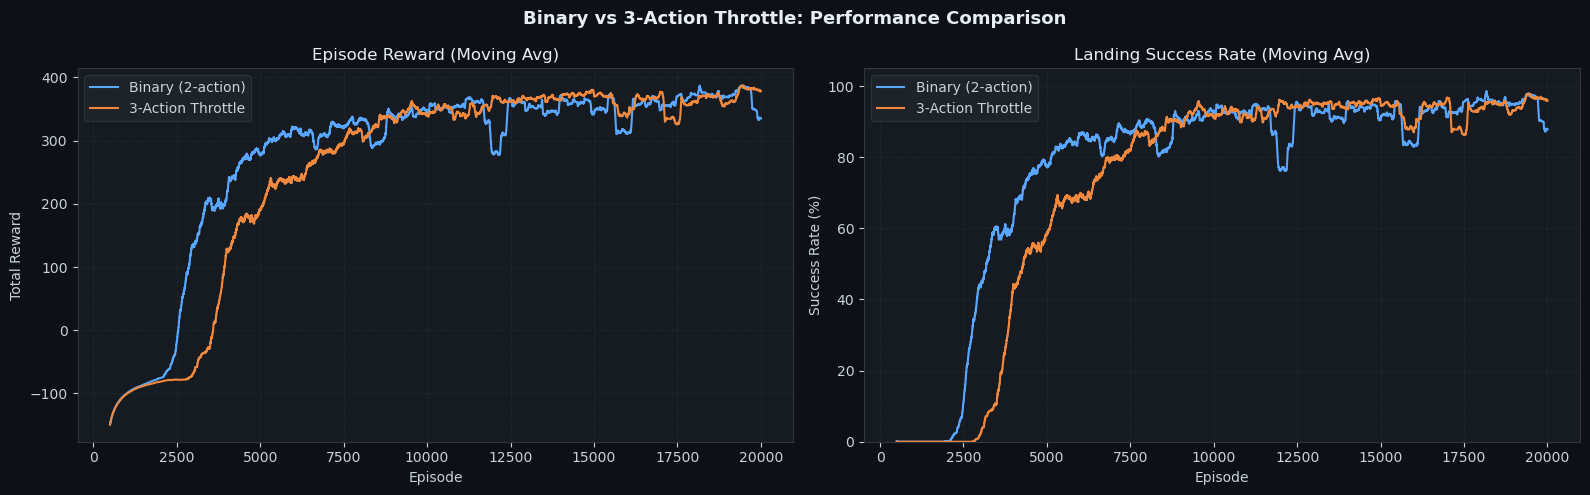


── Bonus Analysis ──────────────────────────────────────────
  Binary    : Final 1000-ep success=92.6%  avg_reward=359.7
  3-Action  : Final 1000-ep success=96.8%  avg_reward=382.4

  Q-table sizes: Binary=18,000  vs  3-Action=27,000 (+50%)
  More actions → finer control → potentially softer landings
  Trade-off: larger state-action space requires more episodes to converge


In [15]:
# ── Compare binary vs 3-action performance ─────────────────────────────────
def compare_agents(binary_rewards, binary_outcomes, bonus_rewards, bonus_outcomes, window=500):
    """
    Side-by-side comparison of binary vs 3-action agent performance.
    """
    def ma(data, w):
        return np.convolve(data, np.ones(w)/w, mode='valid')

    def success_series(outcomes):
        return [1.0 if o == 'soft_catch' else 0.0 for o in outcomes]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle('Binary vs 3-Action Throttle: Performance Comparison',
                 color='#e6edf3', fontsize=13, fontweight='bold')

    labels = ['Binary (2-action)', '3-Action Throttle']
    colors = ['#58a6ff', '#f0883e']
    reward_data  = [binary_rewards, bonus_rewards]
    success_data = [success_series(binary_outcomes), success_series(bonus_outcomes)]

    for ax in axes:
        ax.set_facecolor('#161b22')
        ax.tick_params(colors='#c9d1d9')
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363d')
        ax.grid(True, color='#21262d', linewidth=0.7, linestyle='--')

    # Left: Reward comparison
    for i, (rd, lbl, col) in enumerate(zip(reward_data, labels, colors)):
        x  = np.arange(window, len(rd) + 1)
        axes[0].plot(x, ma(rd, window), color=col, linewidth=1.5, label=lbl)
    axes[0].set_title('Episode Reward (Moving Avg)', color='#e6edf3')
    axes[0].set_xlabel('Episode', color='#c9d1d9')
    axes[0].set_ylabel('Total Reward', color='#c9d1d9')
    axes[0].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#c9d1d9')

    # Right: Success rate comparison
    for i, (sd, lbl, col) in enumerate(zip(success_data, labels, colors)):
        x  = np.arange(window, len(sd) + 1)
        axes[1].plot(x, ma(sd, window)*100, color=col, linewidth=1.5, label=lbl)
    axes[1].set_title('Landing Success Rate (Moving Avg)', color='#e6edf3')
    axes[1].set_xlabel('Episode', color='#c9d1d9')
    axes[1].set_ylabel('Success Rate (%)', color='#c9d1d9')
    axes[1].set_ylim(0, 105)
    axes[1].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#c9d1d9')

    plt.tight_layout()
    plt.savefig('comparison_curve.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

    # Text summary
    print("\n── Bonus Analysis ──────────────────────────────────────────")
    last = 1000
    for name, outcomes, rewards in [('Binary',  binary_outcomes, binary_rewards),
                                    ('3-Action', bonus_outcomes,  bonus_rewards)]:
        s = outcomes[-last:].count('soft_catch') / last * 100
        r = np.mean(rewards[-last:])
        print(f"  {name:<10}: Final {last}-ep success={s:.1f}%  avg_reward={r:.1f}")
    print("\n  Q-table sizes: Binary=18,000  vs  3-Action=27,000 (+50%)")
    print("  More actions → finer control → potentially softer landings")
    print("  Trade-off: larger state-action space requires more episodes to converge")


compare_agents(episode_rewards, episode_outcomes, bonus_rewards, bonus_outcomes)

---
## Design Questions — Report Summary

### Q1: Terminal Velocity
Terminal velocity ≈ **−82.8 m/s**, far exceeding the −3.0 m/s safe catch limit (27× too fast). The agent **must** actively use the spin-drive to survive.

### Q2: Maximum Net Acceleration
Net acceleration with thrust ON, v=0 is **+11.3 m/s²** (upward). Thrust can overpower gravity, creating the **Cowardly Agent** risk: the agent could simply hover forever and avoid the mission.

### Q3: Memory in the Storm (Wind TPM)
The Transition Probability Matrix gives wind **atmospheric inertia** via high self-loop probabilities (Gale→Gale: P=0.70). This produces autocorrelated, realistic weather patterns rather than the chaotic flickering of a random die roll. The Markov property holds because the next wind state depends only on the *current* wind state.

### Q4: Exploration vs. Exploitation
After 5,000 episodes: ε ≈ **0.0067** (0.67%). The agent is **99.3% exploiting** — almost fully greedy, with only a tiny residual exploration buffer.

### Q5: Cowardly Agent Pitfalls
- Heavy crash + tiny fuel → agent hovers forever to avoid death.
- Sparse reward only → credit assignment failure; agent never finds the goal via random exploration.
- **Fix:** time pressure (−0.1/step) + proportional crash penalty (−|v|) + runaway penalty force the agent to commit to descent.

### Q6: The Asymptote of Reward
Perfect scores are mathematically impossible because: (a) time-pressure and fuel costs are inescapable, (b) stochastic wind forces suboptimal extra burns, (c) discretization error prevents the agent from operating on the true optimal continuous trajectory.

---
> *"Amaze! Probe lands safe. Rocky is very happy."* 🪨